# 11 — Reconstructing a shower

Every notebook so far goes *forwards*: from a shower to a field, from a field
to a voltage, from a voltage to ADC counts. This one goes *backwards*. Given
what the antennas recorded — when the pulse peaked and how big it was — it
recovers where the shower came from, where it was brightest, and roughly how
much energy it carried.

That is the job of `grand.analysis`, Marion Guelfand's reconstruction package,
merged into `dev-next` in September 2026 from the `dev_marion` branch.

The notebook works on showers **it makes itself**: it generates arrival times
and amplitudes with the package's own forward models for a shower whose answer
it knows, hands them to the fits, and checks that the answer comes back. That
is the fastest way to see what each fit needs and what it returns, and it is
exactly what the package's tests do. Section 8 then opens the reconstruction
results for ten real GP13 cosmic-ray candidates that ship with the examples.

**What this does not show**: that the models describe nature. Recovering a
shower from times the model itself generated proves the fits are consistent
with their models, not that the models are right. Checking them against
simulated showers with a known answer is the next step, and has not been done
yet — section 10 says what that would take.

**Prerequisites**: the `grand-dev` environment, which carries `iminuit`. Outside
it, `pip install -e ".[analysis]"`.

## 1. The chain, before any code

A reconstruction runs four fits in order, each starting from the one before.
This is the order `examples/analysis/main_AOI.py` uses on real data.

| Step | Function | Uses | Gives |
|---|---|---|---|
| 1. Plane wave | `fit.PWF_semianalytical` | peak times | direction (θ, φ) |
| 2. Spherical wave | `fit.recons_swf` | peak times, step 1 | direction, distance to the source, emission time |
| 3. Angular distribution (ADF) | `fit.recons_ADF` | peak amplitudes, steps 1–2 | direction, width of the Cherenkov ring, amplitude scale |
| 4. Energy proxy | `en.recons_energy_from_voltage` | step 3 | electromagnetic energy |

The first two use only *when* the pulse arrived; the third only *how big* it
was. That split makes the ADF fit a second, independent measurement of the
direction — with one qualification, in section 5: its search is confined to a
small box around the timing answer.

**Conventions, shared with the rest of GRANDlib.**

- **Frame**: x North, y West, z Up, in metres, with the origin at the centre of
  the array. Heights are *above sea level*: the fits put the ground at
  `constants.groundAltitude`, 1231 m, the GP13 site.
- **Angles** in radians, and they say where the shower **comes from**: zenith 0
  is a shower falling straight down, azimuth 0 one arriving from the North,
  azimuth 90° one arriving from the West. The
  [coordinates page](https://grand-mother.github.io/grand-docs/coordinates.html)
  states this convention, and `tests/geo/test_angle_convention.py` pins it.
- **Times** in seconds.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import grand.analysis.constants as cons
import grand.analysis.fitting as fit
import grand.analysis.geom as geom
import grand.analysis.energy_reco as en
from grand.analysis.coords.array_shower import shower_direction_vector

print("ground altitude      %.0f m" % cons.groundAltitude)
print("refractive index     %.6f (at ground, used by the plane-wave fit)" % cons.n_atm)
print("speed of light       %.0f m/s" % cons.c_light)

ground altitude      1231 m
refractive index     1.000136 (at ground, used by the plane-wave fit)
speed of light       299792458 m/s


The package is organised by what each part does. Its top level also exposes
short aliases — `grand.analysis.fit`, `.geom`, `.en`, `.sig`, `.co`, `.cons` —
which is how the example scripts use it; the full names above say more when
read cold.

One property worth knowing: `constants.Bn`, the direction of the geomagnetic
field at the site, is computed **the first time it is read**, not when the
package is imported. Computing it needs the compiled core and the geomagnetic
model, so evaluating it at import made every `import grand.analysis` depend on
both — and broke the documentation build, which runs without them.

In [2]:
print("Bn (x North, y West, z Up) =", np.round(cons.Bn, 3))
print("inclination below horizon  = %.1f deg" % np.degrees(np.arcsin(-cons.Bn[2])))

Bn (x North, y West, z Up) = [ 0.472  0.    -0.881]
inclination below horizon  = 61.8 deg


## 2. An array to reconstruct with

The fits need antenna positions. Rather than invent a layout, this uses the
real one: the GP13 positions surveyed by RTK, which ship with the examples
beside the scripts that use them.

The file is in a **different frame** from the fits: its columns are East,
North and height above the array, not North, West and height above sea level.
Getting this conversion wrong rotates every reconstructed azimuth by 90°, and
nothing downstream would complain, so it is spelled out here exactly as
`main_AOI.py` does it:

- x (North) = the file's second coordinate
- y (West) = minus the file's first coordinate (East)
- z = the file's height + `groundAltitude`

The example also drops detector units 0–15, which are not part of GP13.

65 antennas, spanning 4.0 km north-south and 6.4 km east-west
heights above the array: -25 to 48 m


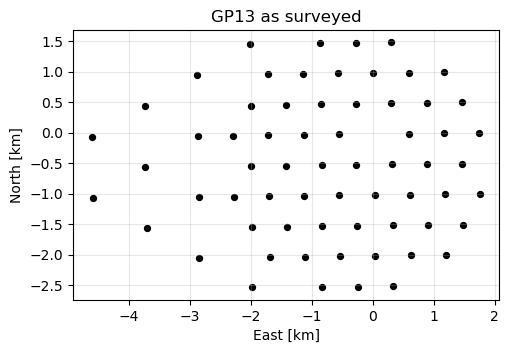

In [3]:
layout = np.loadtxt("../examples/analysis/_gp13_65_rtksort.txt")
du_id, east, north, height = layout.T
keep = ~((du_id >= 0) & (du_id <= 15))
du_id, east, north, height = du_id[keep], east[keep], north[keep], height[keep]

# The fits' frame: x North, y West, z Up above sea level.
ANTENNAS = np.column_stack([north, -east, height + cons.groundAltitude])

print("%d antennas, spanning %.1f km north-south and %.1f km east-west"
      % (len(ANTENNAS), np.ptp(north) / 1e3, np.ptp(east) / 1e3))
print("heights above the array: %.0f to %.0f m" % (height.min(), height.max()))

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(east / 1e3, north / 1e3, s=18, c="k")
ax.set_xlabel("East [km]")
ax.set_ylabel("North [km]")
ax.set_title("GP13 as surveyed")
ax.set_aspect("equal")
ax.grid(alpha=0.3)
plt.show()

The plot uses East to the right and North up, as a map would. Keep that in
mind when reading the azimuths below: in GRAND's frame azimuth grows from
North *towards West*, so on a map it runs anticlockwise.

## 3. Step 1 — the plane wave

Far from the shower, the radio front is close to a plane moving along the
shower axis at the speed of light in air. An antenna at position
$\mathbf{x}_i$ then sees the pulse at

$$ c\,t_i / n \;=\; -\,\mathbf{k}\cdot\mathbf{x}_i \;+\; \text{const}, \qquad
\mathbf{k} = -(\sin\theta\cos\varphi,\; \sin\theta\sin\varphi,\; \cos\theta), $$

where $\mathbf{k}$ is the direction the shower *travels* — hence the minus
sign, since $(\theta, \varphi)$ say where it comes from.

This is linear in the three components of $\mathbf{k}$, so it can be solved
almost in closed form, with no starting guess and no local minima.
`PWF_semianalytical` does that. `PWF_model` is the same equation run forwards,
which is what generates the times here.

Pick a shower, generate its times, fit them:

In [4]:
ZENITH, AZIMUTH = 75.0, 40.0                  # degrees, "comes from"
truth = np.deg2rad([ZENITH, AZIMUTH])

times = fit.PWF_model(truth, ANTENNAS)       # seconds, one per antenna
theta, phi = fit.PWF_semianalytical(ANTENNAS, times)

print("true       zenith %8.4f   azimuth %8.4f  deg" % (ZENITH, AZIMUTH))
print("fitted     zenith %8.4f   azimuth %8.4f  deg" % tuple(np.degrees([theta, phi])))
print("arrivals span %.1f microseconds across the array" % (np.ptp(times) * 1e6))

true       zenith  75.0000   azimuth  40.0000  deg
fitted     zenith  75.0000   azimuth  40.0000  deg
arrivals span 16.8 microseconds across the array


Exact, as it should be: the times came from the same model the fit inverts.

Real times are not exact. The example scripts assume a 5 ns timing
uncertainty, so add 5 ns of Gaussian jitter and fit again — three hundred
times, to see the spread rather than one lucky draw. The semi-analytical fit
needs no iterations, so this is quick.

with 5 ns jitter, over 300 draws:
  zenith   bias -0.0013 deg   spread 0.0319 deg
  azimuth  bias -0.0003 deg   spread 0.0079 deg


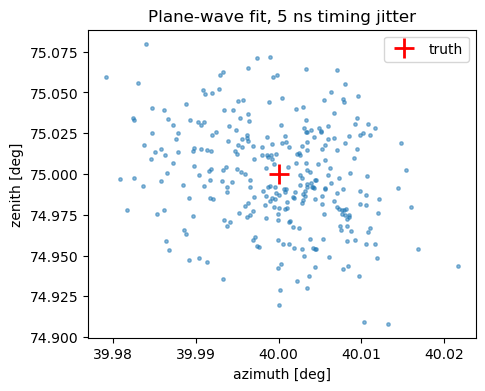

In [5]:
SIGMA_T = 5e-9                               # seconds
rng = np.random.default_rng(1)

fits = np.degrees([fit.PWF_semianalytical(ANTENNAS, times + rng.normal(0, SIGMA_T, len(times)))
                   for _ in range(300)])
bias = fits.mean(axis=0) - [ZENITH, AZIMUTH]
spread = fits.std(axis=0)
print("with %.0f ns jitter, over 300 draws:" % (SIGMA_T * 1e9))
print("  zenith   bias %+.4f deg   spread %.4f deg" % (bias[0], spread[0]))
print("  azimuth  bias %+.4f deg   spread %.4f deg" % (bias[1], spread[1]))

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(fits[:, 1], fits[:, 0], s=6, alpha=0.5)
ax.plot(AZIMUTH, ZENITH, "r+", ms=14, mew=2, label="truth")
ax.set_xlabel("azimuth [deg]")
ax.set_ylabel("zenith [deg]")
ax.set_title("Plane-wave fit, 5 ns timing jitter")
ax.legend()
plt.show()

Hundredths of a degree, and noticeably worse in zenith than in azimuth. That
asymmetry is geometry, not a flaw: at 75° the shower arrives nearly
horizontally, so the array — which is almost flat — sees the azimuth along its
full width, while the zenith has to be read from small height-dependent
delays.

The fit also offers a χ², `PWF_loss`. It is what `main_AOI.py` stores as
`chi2_pwf`, divided by the degrees of freedom (antennas − 2). With the right
`sigma` and a model that fits, the reduced value should be near 1:

In [6]:
noisy = times + rng.normal(0, SIGMA_T, len(times))
best = fit.PWF_semianalytical(ANTENNAS, noisy)
chi2 = fit.PWF_loss(best, ANTENNAS, noisy, sigma=SIGMA_T)
print("chi2 / ndf = %.2f   (ndf = %d)" % (chi2 / (len(ANTENNAS) - 2), len(ANTENNAS) - 2))

chi2 / ndf = 1.11   (ndf = 63)


## 4. Step 2 — the spherical wave

The plane is an approximation. The emission comes from a region around the
shower maximum, some tens of kilometres away for an inclined shower, so the
real front is a sphere centred there. The spherical-wave model adds that
source's distance $r$ along the axis and its emission time $t_s$:

$$ c\,(t_i - t_s) \;=\; \bar n_i\,\lVert \mathbf{x}_i - \mathbf{X}_{\rm source} \rVert , $$

with $\bar n_i$ the refractive index averaged along the path from source to
antenna — a real atmosphere, not the constant $n$ of the plane wave.

Generate times from a source 40 km away and see what the plane wave makes of
them:

In [7]:
DISTANCE = 40_000.0                           # metres, from the ground point to the source
EMITTED = -DISTANCE / cons.c_light            # the source emits before the front reaches the array

sphere_times = fit.SWF_model(truth[0], truth[1], DISTANCE, EMITTED, ANTENNAS)
plane = np.degrees(fit.PWF_semianalytical(ANTENNAS, sphere_times))
print("plane-wave fit to a spherical front:  zenith %.3f  azimuth %.3f  deg"
      % tuple(plane))
print("  off by                              %+.3f         %+.3f"
      % tuple(plane - [ZENITH, AZIMUTH]))

plane-wave fit to a spherical front:  zenith 73.974  azimuth 38.348  deg
  off by                              -1.026         -1.652


More than a degree in each angle, with no noise at all: that is the curvature
alone, a source 40 km away seen across 6 km of array. It is at least thirty times
the spread the timing allows, so fitting the sphere is not a refinement here — it
is necessary.

`recons_swf` does that by differential evolution, a global search over bounds
built around the plane-wave answer. It is much slower than step 1 — the loss is
a Python loop over antennas that recomputes the refractive index each time — so
with all 65 antennas this cell takes about half a minute. `maxiter=300` is
enough here; the example scripts leave the default of 1000.

In [8]:
import time

started = time.perf_counter()
theta_s, phi_s, r_s, t_s = fit.recons_swf(np.deg2rad(plane[0]), np.deg2rad(plane[1]),
                                          sphere_times, ANTENNAS, maxiter=300)
print("took %.1f s" % (time.perf_counter() - started))
print("zenith   %.4f deg   (true %.1f)" % (np.degrees(theta_s), ZENITH))
print("azimuth  %.4f deg   (true %.1f)" % (np.degrees(phi_s), AZIMUTH))
print("distance %.1f m     (true %.1f)" % (r_s, DISTANCE))
print("t_s      %.4e s  (true %.4e)" % (t_s, EMITTED))

took 29.3 s
zenith   75.0000 deg   (true 75.0)
azimuth  40.0000 deg   (true 40.0)
distance 40000.0 m     (true 40000.0)
t_s      -1.3343e-04 s  (true -1.3343e-04)


The direction, the distance and the emission time all come back.

The distance turns into a point with `compute_Xsource_cartesian_coords`. Two
things about it catch people out:

- it returns shape **(1, 3)**, not (3,), and every later function wants (3,),
  so `main_AOI.py` takes `[0]` straight away — do the same;
- the point is measured from `(0, 0, groundAltitude)`, the centre of the array
  *on the ground*, so its z is a height above sea level.

`recons_swf` also takes a `sigma` argument that it **ignores**. That changes no
result — scaling a χ² by a constant does not move its minimum — but a caller
who passes a timing uncertainty expecting it to weight the fit gets an
unweighted fit. The package's tests pin that behaviour so a fix will be
noticed.

In [9]:
xsource = fit.compute_Xsource_cartesian_coords(theta_s, phi_s, r_s)
print("as returned:", xsource.shape)
XSOURCE = xsource[0]
print("source at   x %.0f m (North)   y %.0f m (West)   z %.0f m (above sea level)"
      % tuple(XSOURCE))

k = shower_direction_vector(theta_s, phi_s)
print("travelling along k =", np.round(k, 3), "  -- downwards and away from where it came from")

as returned: (1, 3)
source at   x 29598 m (North)   y 24835 m (West)   z 11584 m (above sea level)
travelling along k = [-0.74  -0.621 -0.259]   -- downwards and away from where it came from


## 5. Step 3 — the angular distribution function

Timing says where the shower came from. The **amplitudes** say it again,
independently. The radio emission is beamed into a narrow cone around the
shower axis, brightest at the Cherenkov angle $\omega_c$ — a fraction of a
degree to about a degree, set by the refractive index along the path. Seen
from the source, each antenna sits at some angle $\omega$ from the axis, and
the ADF models its peak amplitude as

$$ A(\omega, \eta) \;=\; \frac{A_0}{\ell}\;
   \frac{1 + \epsilon\cos\eta}
        {1 + 4\left[\big(\tan^2\omega / \tan^2\omega_c - 1\big)/\delta\omega\right]^2} , $$

a ring of width $\delta\omega$ peaking at $\omega_c$, falling with the distance
$\ell$ to the source, and lopsided by $\epsilon\cos\eta$ around the axis
because the geomagnetic and charge-excess emission add on one side and cancel
on the other.

`ADF_parameters` evaluates all of that for a given shower. Give it the shower
from step 2, a ring width of 2 and an amplitude scale $A_0$, and it returns
each antenna's angles and predicted amplitude:

In [10]:
WIDTH, SCALE = 2.0, 5.0e7                     # ring width; amplitude scale in ADC counts x metres

eta, omega, omega_cr, ell, amplitude = fit.ADF_parameters(
    truth[0], truth[1], WIDTH, SCALE, ANTENNAS, XSOURCE)

print("Cherenkov angle at these antennas: %.3f to %.3f deg"
      % (np.degrees(omega_cr).min(), np.degrees(omega_cr).max()))
print("antennas' angle from the axis:     %.3f to %.3f deg"
      % (np.degrees(omega).min(), np.degrees(omega).max()))
print("brightest antenna                  %.0f ADC" % amplitude.max())

Cherenkov angle at these antennas: 0.701 to 0.731 deg
antennas' angle from the axis:     0.250 to 6.367 deg
brightest antenna                  1287 ADC


Only antennas near the ring see much. A real event is the handful that
triggered, so keep the ones above a quarter of the peak, and add 7.5 %
scatter — the relative uncertainty that `ADF_loss` assumes by default:

19 of 65 antennas triggered


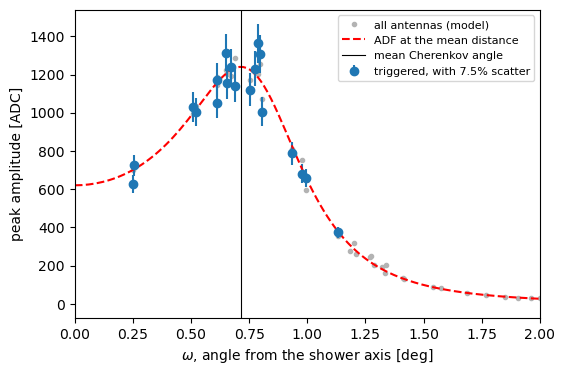

In [11]:
TRIGGERED = amplitude > 0.25 * amplitude.max()
X_T = ANTENNAS[TRIGGERED]
measured = amplitude[TRIGGERED] * (1 + rng.normal(0, 0.075, TRIGGERED.sum()))
print("%d of %d antennas triggered" % (TRIGGERED.sum(), len(ANTENNAS)))

w_curve, adf_curve = fit.ADF_fun(np.mean(ell[TRIGGERED]), SCALE,
                                 np.mean(omega_cr[TRIGGERED]), WIDTH)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.degrees(omega), amplitude, ".", color="0.7", label="all antennas (model)")
ax.errorbar(np.degrees(omega[TRIGGERED]), measured, yerr=0.075 * measured,
            fmt="o", color="C0", label="triggered, with 7.5% scatter")
ax.plot(np.degrees(w_curve), adf_curve, "--r", label="ADF at the mean distance")
ax.axvline(np.degrees(omega_cr[TRIGGERED].mean()), color="k", lw=0.8,
           label="mean Cherenkov angle")
ax.set_xlim(0, 2)
ax.set_xlabel(r"$\omega$, angle from the shower axis [deg]")
ax.set_ylabel("peak amplitude [ADC]")
ax.legend(fontsize=8)
plt.show()

This is the same plot `examples/analysis/display.py` draws for each real
event. Even the noiseless grey points spread about the dashed curve: that is
the $\cos\eta$ asymmetry, which makes antennas at the same $\omega$ on
opposite sides of the axis differ, and their different distances $\ell$. The
blue points add the 7.5 % scatter.

`recons_ADF` fits four numbers — zenith, azimuth, width and scale — starting
from the plane-wave direction and holding the source fixed where the
spherical wave put it:

In [12]:
theta_pw, phi_pw = fit.PWF_semianalytical(X_T, sphere_times[TRIGGERED])
started = time.perf_counter()
theta_a, phi_a, width_a, scale_a = fit.recons_ADF(theta_pw, phi_pw, measured, X_T, XSOURCE)
print("took %.1f s" % (time.perf_counter() - started))
print("zenith  %.3f deg  (true %.1f)" % (np.degrees(theta_a), ZENITH))
print("azimuth %.3f deg  (true %.1f)" % (np.degrees(phi_a), AZIMUTH))
print("width   %.3f      (true %.1f)" % (width_a, WIDTH))
print("scale   %.3e  (true %.1e)" % (scale_a, SCALE))

took 1.6 s
zenith  75.013 deg  (true 75.0)
azimuth 39.996 deg  (true 40.0)
width   1.991      (true 2.0)
scale   4.913e+07  (true 5.0e+07)


**The ADF fit is confined, and it does not say when it hits the wall.** It is a
MIGRAD minimisation inside fixed bounds: zenith within ±2° of the plane-wave
answer, azimuth within ±1°, width between 1.25 and 3, scale between 10⁶ and
10¹⁰. A result sitting on one of those bounds is where the minimiser was
stopped, not where the data put it, and it looks like any other result:
nothing in `recons_ADF` or `main_AOI.py` flags it. The check is short:

In [13]:
def on_a_bound(theta, phi, width, scale, theta_pwf, phi_pwf):
    """Names the ADF parameters that sit on recons_ADF's bounds."""
    edges = {"zenith": (theta, theta_pwf - np.deg2rad(2), theta_pwf + np.deg2rad(2)),
             "azimuth": (phi, phi_pwf - np.deg2rad(1), phi_pwf + np.deg2rad(1)),
             "width": (width, 1.25, 3.0),
             "scale": (scale, 1e6, 1e10)}
    return [name for name, (value, low, high) in edges.items()
            if np.isclose(value, low, rtol=1e-5) or np.isclose(value, high, rtol=1e-5)]


print("parameters on a bound:", on_a_bound(theta_a, phi_a, width_a, scale_a, theta_pw, phi_pw) or "none")

parameters on a bound: none


None here. Section 8 runs the same check on real events, where the answer is
different.

The bounds have a second consequence, worth having in mind before comparing
directions: the ADF direction **cannot** differ from the plane-wave one by more
than 2° in zenith or 1° in azimuth. Agreement within those limits is partly by
construction.

## 6. Step 4 — an energy

The fitted scale $A_0$ grows with the shower's electromagnetic energy. It also
grows with $\sin\alpha$, the sine of the angle between the shower axis and the
geomagnetic field, because the dominant emission comes from the field pulling
charges sideways: a shower along the field emits almost nothing. Dividing that
out and applying a straight-line calibration fitted on simulations
([arXiv:2507.04324](https://arxiv.org/abs/2507.04324)) gives

$$ E_{\rm em} = \max\!\left(\frac{A_0/\sin\alpha - b}{a},\, 0\right) \times 10^{18}\ {\rm eV},
\qquad a = 1.96\times10^{7},\; b = 7.90\times10^{6}. $$

In [14]:
sin_alpha = geom.sin_geomag_angle(theta_a, phi_a)
energy = en.recons_energy_from_voltage(scale_a, sin_alpha)
true_energy = en.recons_energy_from_voltage(SCALE, geom.sin_geomag_angle(*truth))

print("sin(alpha)                  %.3f" % sin_alpha)
print("energy from the fitted A0   %.3g eV" % energy)
print("energy from the true A0     %.3g eV" % true_energy)

sin(alpha)                  0.993
energy from the fitted A0   2.12e+18 eV
energy from the true A0     2.17e+18 eV


Read it for what it is: the package calls it "just a first proxy". The
calibration is in ADC counts, so it belongs to one electronics chain; it
ignores the charge-excess share, which depends on the zenith; and a scale
below $b\,\sin\alpha$ is clamped to **zero** rather than flagged — the
docstring notes that such events may still be genuine cosmic rays.

The function's docstring also says it takes arrays. It does not: it calls
Python's `max`, which cannot compare an array with 0, so an array raises
`ValueError`. Until that is fixed (it needs `np.maximum`), loop, or vectorise
it yourself:

In [15]:
scales = np.array([5e6, 5e7, 1e8])
try:
    en.recons_energy_from_voltage(scales, sin_alpha)
except ValueError as error:
    print("array input:", type(error).__name__, "-", str(error)[:60], "...")

per_event = np.vectorize(en.recons_energy_from_voltage)(scales, sin_alpha)
print("vectorised:", ["%.3g eV" % e for e in per_event])

array input: ValueError - The truth value of an array with more than one element is am ...
vectorised: ['0 eV', '2.17e+18 eV', '4.74e+18 eV']


The first of those is clamped to zero: $5\times10^6 / \sin\alpha$ is below
$b$, so the formula goes negative — the proxy cannot see a shower that faint,
and says 0 rather than "unknown".

## 7. The whole chain, as the example runs it

Everything above, in the order and with the arguments that
`examples/analysis/main_AOI.py` uses on real data, on one noisy synthetic
event: 5 ns timing jitter and 7.5 % amplitude scatter on the triggered
antennas only.

In [16]:
def reconstruct(Xants, peak_times, peak_amps, sigma_t=5e-9):
    """The four steps of main_AOI.py, returning a dict of results."""
    n = len(Xants)
    theta_pwf, phi_pwf = fit.PWF_semianalytical(Xants, peak_times, sigma=sigma_t)
    chi2_pwf = fit.PWF_loss((theta_pwf, phi_pwf), Xants, peak_times, sigma=sigma_t) / (n - 2)

    theta_swf, phi_swf, r_xmax, t_s = fit.recons_swf(theta_pwf, phi_pwf, peak_times, Xants,
                                                     sigma=sigma_t, maxiter=300)
    Xsource = fit.compute_Xsource_cartesian_coords(theta_swf, phi_swf, r_xmax)[0]

    theta_adf, phi_adf, width, scale = fit.recons_ADF(theta_pwf, phi_pwf, peak_amps, Xants, Xsource)
    chi2_adf = fit.ADF_loss((theta_adf, phi_adf, width, scale), peak_amps, Xants, Xsource) / (n - 4)

    energy = en.recons_energy_from_voltage(scale, geom.sin_geomag_angle(theta_adf, phi_adf))
    return dict(pwf=np.degrees([theta_pwf, phi_pwf]), chi2_pwf=chi2_pwf,
                swf=np.degrees([theta_swf, phi_swf]), r_xmax=r_xmax, Xsource=Xsource,
                adf=np.degrees([theta_adf, phi_adf]), width=width, scale=scale,
                chi2_adf=chi2_adf, energy=energy)


peak_times = sphere_times[TRIGGERED] + rng.normal(0, 5e-9, TRIGGERED.sum())
started = time.perf_counter()
result = reconstruct(X_T, peak_times, measured)
print("took %.1f s for %d antennas\n" % (time.perf_counter() - started, len(X_T)))
print("            zenith   azimuth")
print("truth      %7.3f   %7.3f" % (ZENITH, AZIMUTH))
for step in ("pwf", "swf", "adf"):
    print("%-9s  %7.3f   %7.3f" % (step.upper(), *result[step]))
print("\nsource distance %.1f km (true %.1f)" % (result["r_xmax"] / 1e3, DISTANCE / 1e3))
print("ADF scale       %.3g (true %.3g)" % (result["scale"], SCALE))
print("chi2/ndf  PWF %.2f   ADF %.2f" % (result["chi2_pwf"], result["chi2_adf"]))
print("energy    %.3g eV (from the true A0: %.3g eV)" % (result["energy"], true_energy))

took 6.8 s for 19 antennas

            zenith   azimuth
truth       75.000    40.000
PWF         75.132    39.944
SWF         75.017    40.010
ADF         75.052    40.015

source distance 35.0 km (true 40.0)
ADF scale       4.2e+07 (true 5e+07)
chi2/ndf  PWF 3.52   ADF 2.07
energy    1.76e+18 eV (from the true A0: 2.17e+18 eV)


The plane wave is off by about a tenth of a degree — less than in section 4,
because the 19 triggered antennas cover a smaller patch and see less of the
curvature — and the spherical and ADF fits bring it to a few hundredths.

The **distance** is 35 km rather than 40. Curvature across a few kilometres is
a small signal, and 5 ns of jitter moves it a lot. The ADF scale follows the
distance, through the $1/\ell$ in the model, and the energy follows the scale,
here about 20 % low. **Direction is what this chain measures well; distance
and energy, much less so.**

The PWF χ²/ndf is well above 1, correctly: the times came from a sphere, and a
plane does not fit them.

## 8. Real events: the GP13 cosmic-ray candidates

The examples directory carries the output of this chain for ten GP13 events
flagged as cosmic-ray candidates between July and October, stored in a
`TRecons` tree — the ROOT tree `grand.analysis` added to the data format. It
holds one entry per event with every intermediate result: 27 fields, from the
peak times and amplitudes it started with to the energy it ended with.

In [17]:
import logging
logging.getLogger("grand").setLevel(logging.ERROR)   # ROOT names every branch it reads

from grand.dataio import TRecons

recons = TRecons("../examples/analysis/recons_CR_candidates.root")
events = recons.get_list_of_events()
print("%d events: (event, run) %s ..." % (len(events), events[:3]))

rows = []
for event_number, run_number in events:
    recons.get_event(event_number, run_number)
    rows.append(dict(
        event=event_number, run=run_number, antennas=recons.du_count,
        pwf=np.degrees([recons.zenith_pwf, recons.azimuth_pwf]),
        swf=np.degrees([recons.zenith_swf, recons.azimuth_swf]),
        adf=np.degrees([recons.zenith_adf, recons.azimuth_adf]),
        r_xmax=recons.r_xmax, width=recons.width, scale=recons.scaling_factor,
        chi2_adf=recons.chi2_adf, energy=recons.energy_elm_voltage,
        Xsource=np.asarray(recons.Xsource)[0], Xants=np.asarray(recons.Xants),
        amps=np.asarray(recons.adf_amplitude), omega_cr=np.mean(recons.omega_cr)))

print("\n  event   run  DUs   zenith  azimuth   (ADF)   source    energy")
for r in rows:
    print("%7d %5d %4d  %7.2f  %7.2f          %5.1f km  %8.2g eV"
          % (r["event"], r["run"], r["antennas"], *r["adf"],
             r["r_xmax"] / 1e3, r["energy"]))

10 events: (event, run) [(479, 10126), (649, 10126), (378, 10127)] ...

  event   run  DUs   zenith  azimuth   (ADF)   source    energy
    479 10126    5    77.03   283.43           65.8 km   4.1e+16 eV
    649 10126    5    76.24   280.18          102.1 km   2.6e+17 eV
    378 10127    7    68.65   181.05           29.1 km   1.1e+17 eV
   1304 10127    7    71.91    25.20          102.6 km     5e+17 eV
    517 10127   13    80.60   185.69           25.6 km   1.2e+18 eV
     93 10127   15    77.30    26.67           26.4 km         0 eV
     76 10127    7    74.52   131.63           19.7 km         0 eV
    150 10127    7    67.77    92.05           35.3 km   6.5e+17 eV
    557 10127    6    75.23   146.08          117.7 km   2.6e+18 eV
     17 10127   13    76.24    82.74           30.1 km         0 eV


Things to read off that table:

- **All ten are inclined**, zenith 68–81°. That is expected rather than a
  quirk of the fit: GP13 is a small, sparse array, and only inclined showers
  light up a footprint big enough to trigger several of its antennas.
- **The source is 20–120 km away**, consistent with the maximum of an inclined
  shower high in a thin atmosphere.
- **Energies run from 4×10¹⁶ to 3×10¹⁸ eV**, and three read exactly 0: those
  were clamped by the proxy, not measured.
- **Five to fifteen antennas an event.** The ADF fit has four free parameters,
  so with five antennas its χ² has one degree of freedom.

Now the quality of each fit: the χ² per degree of freedom of each step, how far
the spherical and ADF directions moved from the plane-wave one, and the bound
check from section 5. The stored χ² fields are **already** divided by the
degrees of freedom — `main_AOI.py` divides before writing — so they are read
as they are. (`display.py` divides `chi2_adf` a second time for its plot
titles, so the value it prints is smaller than the one stored.)

In [18]:
print("  event   chi2/ndf: PWF    SWF    ADF    SWF-PWF (zen, azi)   ADF-PWF (zen, azi)   on a bound")
bounded = 0
for event_number, run_number in events:
    recons.get_event(event_number, run_number)
    pwf = np.array([recons.zenith_pwf, recons.azimuth_pwf])
    swf = np.degrees([recons.zenith_swf, recons.azimuth_swf] - pwf)
    adf = np.degrees([recons.zenith_adf, recons.azimuth_adf] - pwf)
    edge = on_a_bound(recons.zenith_adf, recons.azimuth_adf, recons.width,
                      recons.scaling_factor, *pwf)
    bounded += bool(edge)
    print("%7d  %13.1f %6.1f %6.1f     %+5.2f %+5.2f         %+5.2f %+5.2f         %s"
          % (event_number, recons.chi2_pwf, recons.chi2_swf, recons.chi2_adf,
             *swf, *adf, ", ".join(edge) or "-"))
print("\n%d of %d ADF fits end on a bound" % (bounded, len(events)))

  event   chi2/ndf: PWF    SWF    ADF    SWF-PWF (zen, azi)   ADF-PWF (zen, azi)   on a bound
    479            1.5    0.8    0.4     -0.09 -1.33         +0.10 -0.25         -
    649            0.3    0.0    0.4     -0.03 -0.87         -0.09 -0.06         width
    378           46.7   42.6    1.6     +0.36 +2.82         +0.06 -0.01         width
   1304           19.7   19.0   69.0     -0.29 -0.14         +0.06 +0.02         width
    517          108.1   81.3   28.5     +0.15 +2.61         +0.56 -0.99         width
     93          151.5   83.9  134.9     -0.07 +2.58         -0.13 +0.08         width
     76           55.1   41.5   20.2     +0.13 -1.99         -0.19 -0.17         width
    150           30.2   24.2   14.9     +0.96 +0.38         +0.05 -0.13         -
    557           24.5   24.3   50.8     +0.11 -0.08         +0.07 +0.00         width
     17           88.6   44.9   18.5     +0.43 -1.63         +0.03 -0.01         width

8 of 10 ADF fits end on a bound


This is where the real data parts company with section 7.

- **Most ADF fits end on a bound**, all of them on the upper limit of the
  ring width. Those widths are where the minimiser was stopped; the amplitude data
  wanted a wider ring than the model allows. The directions and energies from
  those fits deserve less weight than the table above suggests.
- **Most timing χ²/ndf are far above 1** — tens to over a hundred — with the
  5 ns timing uncertainty the script assumes. Either the real timing error is
  several times larger, or the fronts are not the spheres the model draws.
  Which one is a question the data in this file cannot settle.
- **The spherical fit moves the azimuth by up to about 3°** from the plane
  wave. The ADF moves it by at most 1°, because that is its bound.

Where they came from, drawn as a sky map looking up — North at the top, West
to the left, the horizon at the edge:

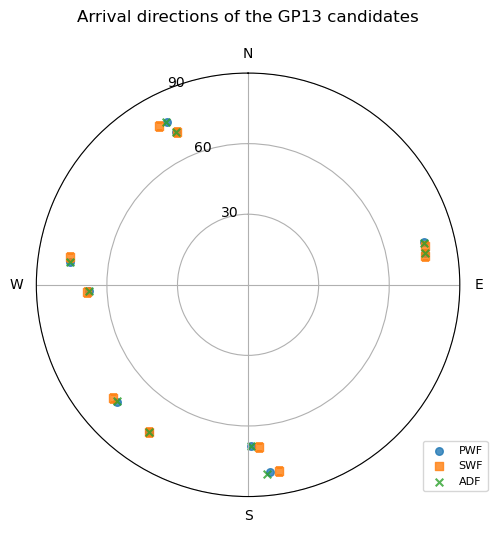

In [19]:
fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(5.5, 5.5))
ax.set_theta_zero_location("N")
ax.set_theta_direction(1)                    # azimuth grows towards West: anticlockwise
for step, marker in (("pwf", "o"), ("swf", "s"), ("adf", "x")):
    zen = np.array([r[step][0] for r in rows])
    azi = np.array([r[step][1] for r in rows])
    ax.scatter(np.deg2rad(azi), zen, marker=marker, s=30, alpha=0.8, label=step.upper())
ax.set_rlim(0, 90)
ax.set_rticks([30, 60, 90])
ax.set_xticks(np.deg2rad([0, 90, 180, 270]))
ax.set_xticklabels(["N", "W", "S", "E"])
ax.set_title("Arrival directions of the GP13 candidates", pad=18)
ax.legend(loc="lower left", bbox_to_anchor=(0.9, 0.0), fontsize=8)
plt.show()

On a sky map the three estimates overlap for every event — two pairs of
events are close enough to share a spot, which is why ten events show as
fewer clusters. Read the overlap with the previous table in mind: a few
degrees is invisible at this scale, and the ADF is held within 1–2° of the
plane wave by its bounds. This picture shows where the candidates came from,
not how well their directions are known.

One event's footprint on the ground, drawn the way `display.py` draws it: the
triggered antennas sized by amplitude, the core where the axis meets the
ground, and the Cherenkov ring — the cone at the mean Cherenkov angle,
intersected with flat ground at `groundAltitude`.

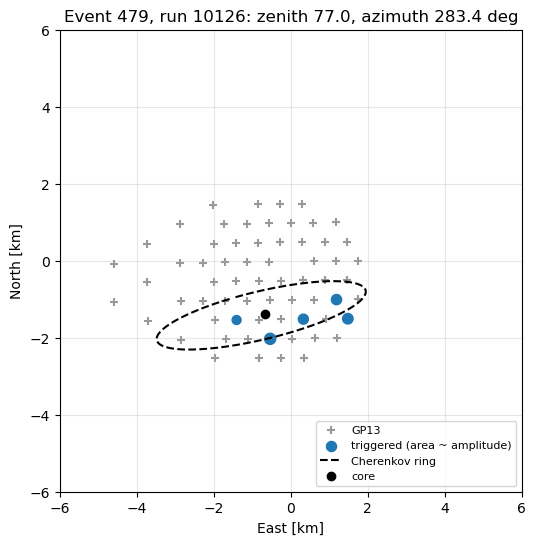

In [20]:
r = rows[0]
k = shower_direction_vector(*np.deg2rad(r["adf"]))
core = geom.compute_core(k, r["Xsource"])
cone = geom.generate_cone_surface_vectors(k, r["omega_cr"], 200)
ring = np.array([geom.compute_core(v, r["Xsource"]) for v in cone])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(east / 1e3, north / 1e3, marker="+", c="0.6", label="GP13")
# The fits' frame is x North, y West; the map wants East right and North up.
ax.scatter(-r["Xants"][:, 1] / 1e3, r["Xants"][:, 0] / 1e3, s=r["amps"] / 2,
           c="C0", label="triggered (area ~ amplitude)")
ax.plot(-ring[:, 1] / 1e3, ring[:, 0] / 1e3, "--k", label="Cherenkov ring")
ax.plot(-core[1] / 1e3, core[0] / 1e3, "ko", label="core")
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect("equal")
ax.set_xlabel("East [km]")
ax.set_ylabel("North [km]")
ax.set_title("Event %d, run %d: zenith %.1f, azimuth %.1f deg" % (r["event"], r["run"], *r["adf"]))
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)
plt.show()

The ring is an ellipse kilometres long: a cone less than a degree wide, cut
by the ground at a grazing angle. Only a handful of antennas sit near it, and
it is those near the ring that trigger — which is why a sparse array sees so
few antennas per shower, and why the denser, larger GP300 matters.
`compute_core` assumes the ground is flat; the site is not, and its docstring
says so.

## 9. On real data

The scripts that produced that file live beside it:

| Script | Reads | Needs |
|---|---|---|
| `examples/analysis/main_AOI.py` | GP80 voltages through `grand.aoi` | the GP80 data at `/sps/grand/data/gp80/` (CC-IN2P3) |
| `examples/analysis/main_DOI.py` | the same through `grand.dataio` directly | the same |
| `examples/analysis/display.py` | `recons_CR_candidates.root` | nothing else — it runs anywhere |

The two `main_*` scripts add the steps this notebook skipped: extracting each
antenna's peak amplitude and time from its traces (`grand.analysis.signals`,
from the Hilbert envelope), and writing the results. They write them
differently — `main_AOI.py` through the `grand.aoi` event, `main_DOI.py`
through a tree object it names `trecons` but creates as a `TShower` — and
which one produced the committed file is not recorded. Their paths are in
`examples/analysis/config.py`; point them at your own copy of the data to run
them elsewhere.

## 10. What has, and has not, been checked

**Checked** (`tests/analysis/test_reconstruction.py`, run in CI): each
timing fit recovers the shower its own model generated, over four directions
from 35° to 85°; the ADF fit recovers direction, width and scale from its own
amplitudes; the χ² vanishes at the truth; the reconstruction uses the "comes
from" convention; the energy formula is the published one.

**Not checked**: whether these models describe real showers. Everything in
sections 3–7 is the package agreeing with itself. The next step is to run the
chain on simulated events — ZHAireS or CoREAS showers through the antenna and
electronics simulation of notebook 06 — where the true direction, Xmax and
energy are known, and measure the bias and resolution. That has not been done
on `dev-next`.

**On real data** (section 8): most of the ten GP13 candidates have timing
χ²/ndf far above 1, and most ADF fits stop on a bound. Those are the first
things to understand before trusting a reconstructed direction or energy.

**Known behaviours to watch for.** Pinned by tests, so a change is noticed:
`recons_swf` ignores `sigma`; `recons_energy_from_voltage` rejects arrays.
Not pinned: `compute_Xsource_cartesian_coords` returns shape (1, 3); an ADF fit
on its bounds is not flagged; `display.py` divides the stored, already
reduced, `chi2_adf` by the degrees of freedom again.

## Where next

- [01 — Coordinate systems](01_coordinates.ipynb) — the frame and the "comes from" convention the fits use
- [06 — From electric field to ADC counts](06_efield_to_adc.ipynb) — the forward chain that the reconstruction inverts
- [12 — The event viewer](12_event_viewer.ipynb) — looking at one simulated event's footprint interactively
- `examples/analysis/` — the scripts that run this chain on GP13 data

<!-- provenance -->
---

*Generated by `notebooks/make_notebooks.py` on 2026-09-24 16:41 UTC, from commit `fb7e2e37` with uncommitted changes, running Python 3.12.14. Edit the generator and rebuild rather than editing this file: a notebook edited in place is overwritten by the next build, and `--check` will say so.*